In [266]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range,
    get_mlruns_info
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [267]:
os.getuid()

1000

In [268]:
DECAY_RATE = 1

start_datetime_str = "2024-11-04 15-18-27"
end_datetime_str = "2024-11-05 08-00-00"

# end_datetime_str = start_datetime_str = "2024-11-04 14-38-04"
# end_datetime_str = start_datetime_str = "2024-10-31 13-46-21"
# end_datetime_str = start_datetime_str = "2024-11-06 11-00-44" # Error of unchanged observation
# end_datetime_str = start_datetime_str = "2024-11-06 12-08-58"

# contain large buffer and reset buffer [true, false]
start_datetime_str = "2024-11-06 12-08-58"
end_datetime_str = "2024-11-06 13-27-35"

# contain large buffer and reset buffer [true, false] with bugfix on robot pursuit
start_datetime_str = "2024-11-07 08-38-32"
end_datetime_str = "2024-11-07 10-41-32"

# end_datetime_str = start_datetime_str = "2024-11-07 11-31-51"
end_datetime_str = start_datetime_str = "2024-11-09 14-13-27"

# Full run at server
start_datetime_str = "2024-11-07 14-35-44"
end_datetime_str = "2024-11-08 04-58-17"

# Test
end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"
end_datetime_str = start_datetime_str = "2024-11-10 22-47-07"
end_datetime_str = start_datetime_str = "2024-11-11 07-38-36"
# end_datetime_str = start_datetime_str = "2024-11-09 20-42-20"


# end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"

# end_datetime_str = start_datetime_str = "2024-11-10 14-18-31"
# end_datetime_str = start_datetime_str = "2024-11-10 16-46-24"


# Full SAC run at server
# start_datetime_str = "2024-11-08 22-32-12"
# end_datetime_str = "2024-11-09 06-05-21"

# SAC with Pushing Object
end_datetime_str = start_datetime_str = "2024-11-11 09-14-40"
end_datetime_str = start_datetime_str = "2024-11-11 11-23-51"

# SAC Line Following on Server
end_datetime_str = start_datetime_str = "2024-11-11 11-51-46"
end_datetime_str = start_datetime_str = "2024-11-11 13-44-04"
end_datetime_str = start_datetime_str = "2024-11-11 14-26-45"

end_datetime_str = start_datetime_str = "2024-11-09 22-07-25"
end_datetime_str = start_datetime_str = "2024-11-12 08-41-57"
end_datetime_str = start_datetime_str = "2024-11-12 11-10-15"

# SAC Line Following on PC
end_datetime_str = start_datetime_str = "2024-11-12 13-17-48"
# Eval
end_datetime_str = start_datetime_str = "2024-11-12 15-35-48"

# # SAC Robot Pursuit on Server
# end_datetime_str = start_datetime_str = "2024-11-12 16-09-49"
# end_datetime_str = start_datetime_str = "2024-11-12 20-07-22"

# # SAC Pushing Object on PC
# end_datetime_str = start_datetime_str = "2024-11-11 19-06-15"
# end_datetime_str = start_datetime_str = "2024-11-11 22-49-30"

# end_datetime_str = "2024-11-13 00-52-41"
# start_datetime_str = "2024-11-12 22-14-24"

# SAC Line Following
end_datetime_str = start_datetime_str = "2024-11-13 10-42-03"

# Only used for pivot table
end_datetime_str = start_datetime_str = "2024-11-13 17-38-28" # Laptop
end_datetime_str = start_datetime_str = "2024-11-13 18-25-28" # Server
end_datetime_str = start_datetime_str = "2024-11-13 19-10-58" # Azure2
end_datetime_str = start_datetime_str = "2024-11-13 20-32-27" # Server
single_load = False

if single_load:
    df = get_df_from_datetime_range(start_datetime_str, 
                                    end_datetime_str, 
                                    decay_rate=DECAY_RATE,
                                    max_iter=np.inf,
                                    validity_check=False,
                                    reload=False,
                                    # backup_dir="/media/tcc/F89F-5CC1/ICLR/backup-data"
                                    )
    
    if start_datetime_str == end_datetime_str:
        actor_df = get_mlruns_info(start_datetime_str, 
                                    end_datetime_str,
                                    reload=False,)
        actor_df["experiment_path"] = df.experiment_path.unique()[0]
else:
    chosen = "train"
    # if chosen == "eval":
    #     # only load eval
    #     files = [
    #         "2024-11-12 15-35-48", # Line Following large
    #         "2024-11-13 10-42-03", # Line Following small

    #         "2024-11-13 07-42-39", # Robot Pursuit large
    #         "2024-11-12 22-09-50", # Robot Pursuit small

    #         "2024-11-13 01-42-56", # Pushing Object small
            
    #     ]
    # else:
    #     # only load train
    #     files = [
    #         "2024-11-12 13-17-48", # Line Following large
    #         "2024-11-13 10-42-03", # Line Following small

    #         "2024-11-12 20-07-22", # Robot Pursuit large
    #         "2024-11-12 22-09-50", # Robot Pursuit small

    #         "2024-11-13 01-42-56", # Pushing Object small
    #     ]
    files = [
        "2024-11-13 17-38-28", # Line Following large
        "2024-11-13 19-10-58", # Line Following small

        "2024-11-13 18-25-28", # Robot Pursuit large
        "2024-11-13 20-32-27", # Robot Pursuit small

        # "2024-11-13 01-42-56", # Pushing Object small
    ]

    final_df = None
    final_actor_dfs = None
    for time_n in files:
        print("time_n:", time_n)
        end_datetime_str = start_datetime_str = time_n
        df = get_df_from_datetime_range(start_datetime_str, 
                                    end_datetime_str, 
                                    decay_rate=DECAY_RATE,
                                    max_iter=np.inf,
                                    validity_check=False,
                                    reload=False,
                                    # backup_dir="/media/tcc/F89F-5CC1/ICLR/backup-data"
                                    )
        actor_df = get_mlruns_info(start_datetime_str, 
                                    end_datetime_str)
        actor_df["experiment_path"] = df.experiment_path.unique()[0]

        if final_df is None:
            final_df = df.copy()
            final_actor_dfs = actor_df.copy()

        else:
            final_df = pd.concat([final_df, df])
            final_actor_dfs = pd.concat([final_actor_dfs, actor_df])
    
    df = final_df
    actor_df = final_actor_dfs
# end_datetime_str = start_datetime_str = "2024-11-11 09-14-40"
# df_2 = get_df_from_datetime_range(start_datetime_str, 
#                                 end_datetime_str, 
#                                 decay_rate=DECAY_RATE,
#                                 max_iter=np.inf,
#                                 validity_check=False,
#                                 reload=False
#                                 )

# df = pd.concat([df, df_2])

# df.head()
actor_df.head()

time_n: 2024-11-13 17-38-28
time_n: 2024-11-13 19-10-58
time_n: 2024-11-13 18-25-28
time_n: 2024-11-13 20-32-27


,time,actor_loss,step_id,run_name,experiment_path
0,1731519598050,0.071572,300,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
1,1731519630504,0.000744,400,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
2,1731519665035,-0.059290,500,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
3,1731519699698,-0.094939,600,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
4,1731519735186,-0.141714,700,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...


In [269]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    buffer_size = row.exp_config["scenario"]["buffer_size"]
    learning_starts = row.exp_config["scenario"]["learning_starts"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    return category, controller, is_reset_buffer, buffer_size, learning_starts
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

tmp = df.apply(extract_columns, axis=1, result_type='expand')
# tmp = df.exp_config.apply(extract_columns)
tmp.columns = ["category", "controller", "is_reset_buffer", "buffer_size", "learning_starts"]
df = pd.concat([df, tmp], axis=1)

df = df.sort_values(["experiment_path", "iteration_id", "step_id"])
df["trained_task"] = df.apply(lambda row: row.task_name if row.phase == "train" else pd.NA, axis=1)
df["trained_task"] = df.trained_task.fillna(method='ffill')
df

/tmp/ipykernel_1173383/3738003492.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["trained_task"] = df.trained_task.fillna(method='ffill')


,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,category,controller,is_reset_buffer,buffer_size,learning_starts,trained_task
0,0.000,0.489796,None,0.489796,1,1,circle_red,0,train,True,...,NaN,NaN,NaN,NaN,LineFollowing,SAC,False,5000,250,circle_red
1,0.000,0.285714,None,0.775510,1,1,circle_red,1,train,True,...,NaN,NaN,NaN,NaN,LineFollowing,SAC,False,5000,250,circle_red
2,0.165,0.244898,None,1.020408,1,1,circle_red,2,train,True,...,NaN,NaN,NaN,NaN,LineFollowing,SAC,False,5000,250,circle_red
3,0.330,0.285714,None,1.306122,1,1,circle_red,3,train,True,...,NaN,NaN,NaN,NaN,LineFollowing,SAC,False,5000,250,circle_red
4,0.495,0.204082,None,1.510204,1,1,circle_red,4,train,True,...,NaN,NaN,NaN,NaN,LineFollowing,SAC,False,5000,250,circle_red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,3.960,0.979592,None,24.857143,1,1037,circle_yellow,895,eval,False,...,NaN,NaN,NaN,NaN,LineFollowing,SAC,False,20000,250,circle_yellow
26,4.125,0.938776,None,25.795918,1,1037,circle_yellow,896,eval,False,...,NaN,NaN,NaN,NaN,LineFollowing,SAC,False,20000,250,circle_yellow
27,4.290,0.979592,None,26.775510,1,1037,circle_yellow,897,eval,False,...,NaN,NaN,NaN,NaN,LineFollowing,SAC,False,20000,250,circle_yellow
28,4.455,0.979592,None,27.755102,1,1037,circle_yellow,898,eval,False,...,NaN,NaN,NaN,NaN,LineFollowing,SAC,False,20000,250,circle_yellow


In [270]:
[c for c in df.columns if "pos" in c]

['robot_position']

In [271]:
pd.Series(tmp.iloc[0], index=["category", "controller", "is_reset_buffer", "buffer_size"])

category           LineFollowing
controller                   SAC
is_reset_buffer            False
buffer_size                20000
Name: 0, dtype: object

In [272]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "buffer_size"]).last()
group_df

time  running_objective current_value  \
controller category      buffer_size                                           
SAC        LineFollowing 5000         4.620           0.000000          None   
                         20000        4.620           0.938776          None   
           RobotPursuit  5000         2.145          10.000000          None   
                         20000        2.211          10.000000          None   

                                      current_undiscounted_value  episode_id  \
controller category      buffer_size                                           
SAC        LineFollowing 5000                          12.204082           1   
                         20000                         28.693878           1   
           RobotPursuit  5000                          20.091710           1   
                         20000                         19.506556           1   

                                      iteration_id        task_name  step_id  \
controller category      buffer_size                                           
SAC        LineFollowing 5000                 1061    circle_yellow      899   
                         20000                1037    circle_yellow      899   
           RobotPursuit  5000                 2084  yellow_cylinder      455   
                         20000                2351  yellow_cylinder      465   

                                     phase  exploration  ... Image pixel 1193  \
controller category      buffer_size                     ...                    
SAC        LineFollowing 5000         eval        False  ...              NaN   
                         20000        eval        False  ...              NaN   
           RobotPursuit  5000         eval        False  ...         0.290196   
                         20000        eval        False  ...         0.290196   

                                      Image pixel 1194  Image pixel 1195  \
controller category      buffer_size                                       
SAC        LineFollowing 5000                      NaN               NaN   
                         20000                     NaN               NaN   
           RobotPursuit  5000                 0.290196          0.290196   
                         20000                0.290196          0.290196   

                                      Image pixel 1196  Image pixel 1197  \
controller category      buffer_size                                       
SAC        LineFollowing 5000                      NaN               NaN   
                         20000                     NaN               NaN   
           RobotPursuit  5000                 0.290196          0.290196   
                         20000                0.290196          0.290196   

                                      Image pixel 1198  Image pixel 1199  \
controller category      buffer_size                                       
SAC        LineFollowing 5000                      NaN               NaN   
                         20000                     NaN               NaN   
           RobotPursuit  5000                 0.290196          0.290196   
                         20000                0.290196          0.290196   

                                      is_reset_buffer  learning_starts  \
controller category      buffer_size                                     
SAC        LineFollowing 5000                   False              250   
                         20000                  False              250   
           RobotPursuit  5000                   False              250   
                         20000                  False              250   

                                         trained_task  
controller category      buffer_size                   
SAC        LineFollowing 5000           circle_yellow  
                         20000          circle_yellow  
           RobotPursuit  5000         yellow_cylinder  
             

In [273]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category', 'buffer_size']),
 ('SAC', 'LineFollowing', 5000))

In [274]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'LineFollowing',  5000),
            ('SAC', 'LineFollowing', 20000),
            ('SAC',  'RobotPursuit',  5000),
            ('SAC',  'RobotPursuit', 20000)],
           names=['controller', 'category', 'buffer_size'])

In [275]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

/tmp/ipykernel_1173383/2743105663.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[group_df.index[0]]


In [276]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [277]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/tcc/huyhoang/irlc_2025/regelum-playground-iclr/venv/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

# Graph

/tmp/ipykernel_1173383/2710623390.py:26: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_1173383/2710623390.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(X_, Y_, degree)
/tmp/ipykernel_1173383/2710623390.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend()
/tmp/ipykernel_1173383/2710623390.py:26: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_1173383/2710623390.py:26: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_1173383/2710623390.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(X_, Y_, degree)
/tmp/ipykernel_1173383/2710623390.py:65: UserWarning: No artists with labels found to put in legend.

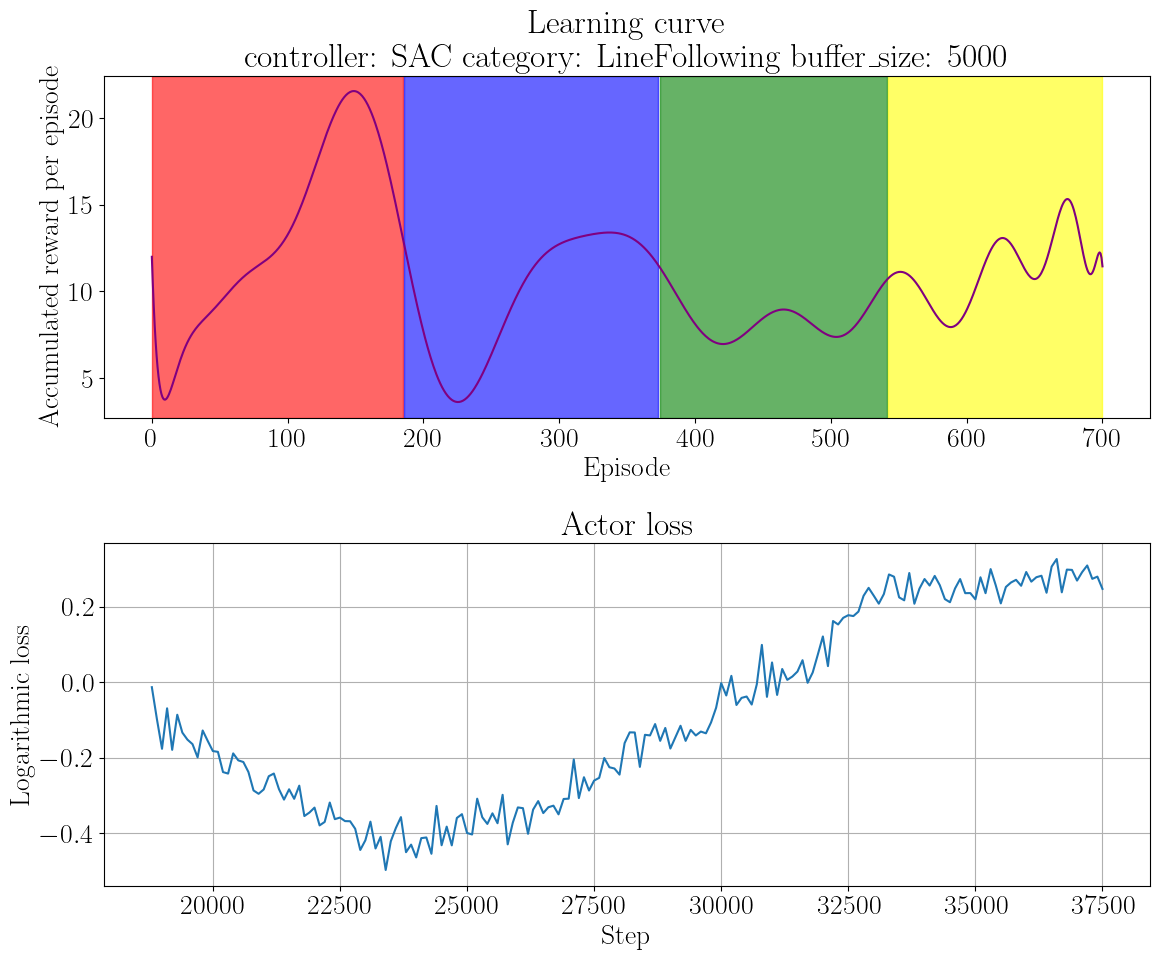

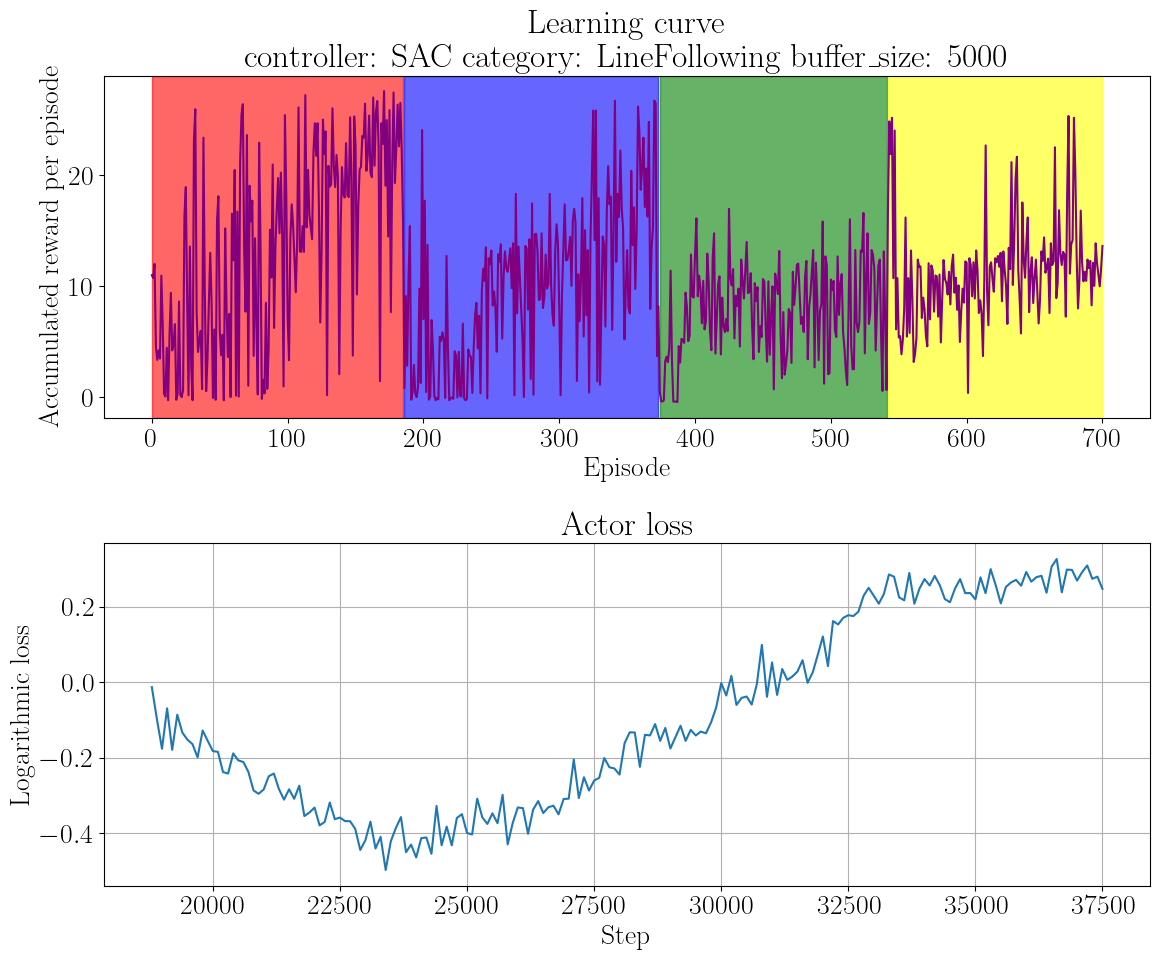

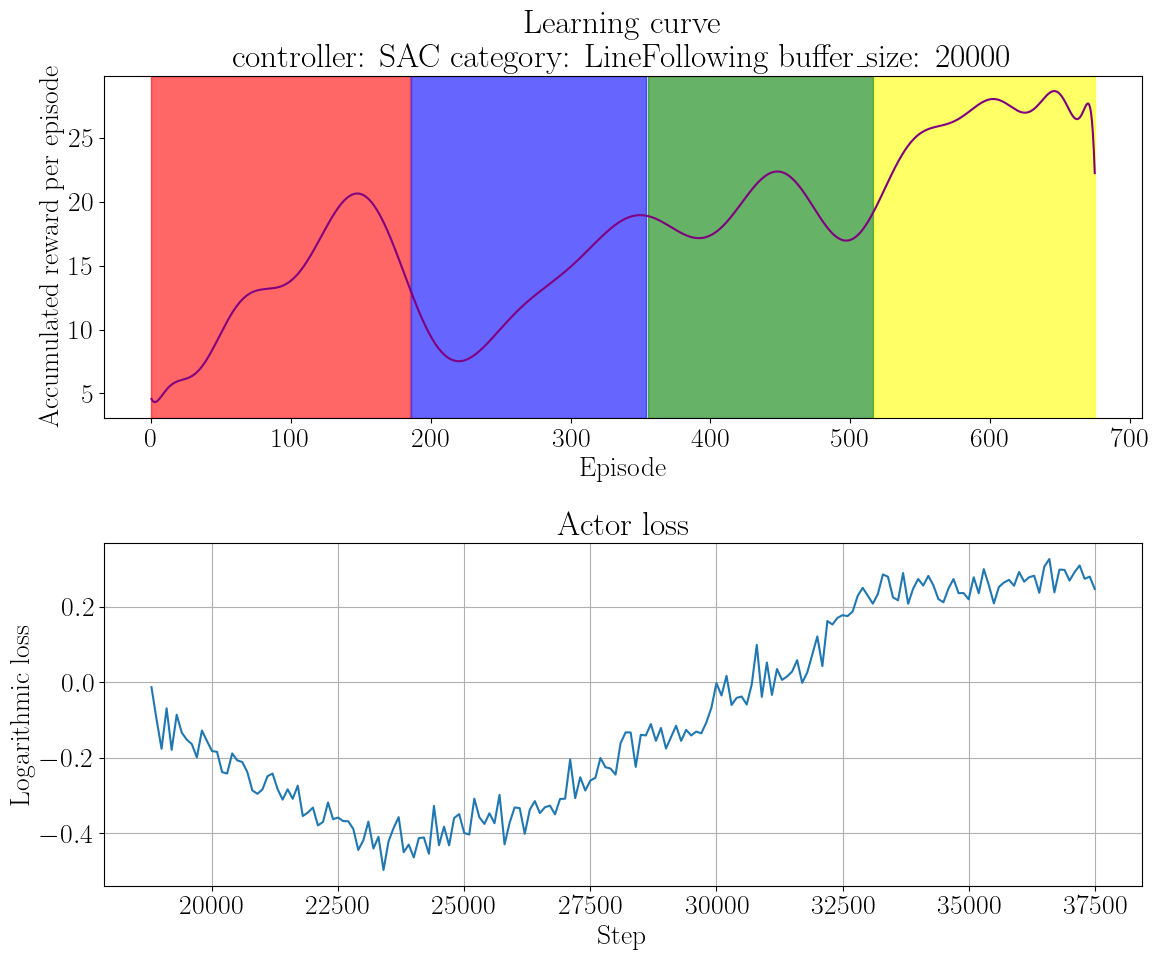

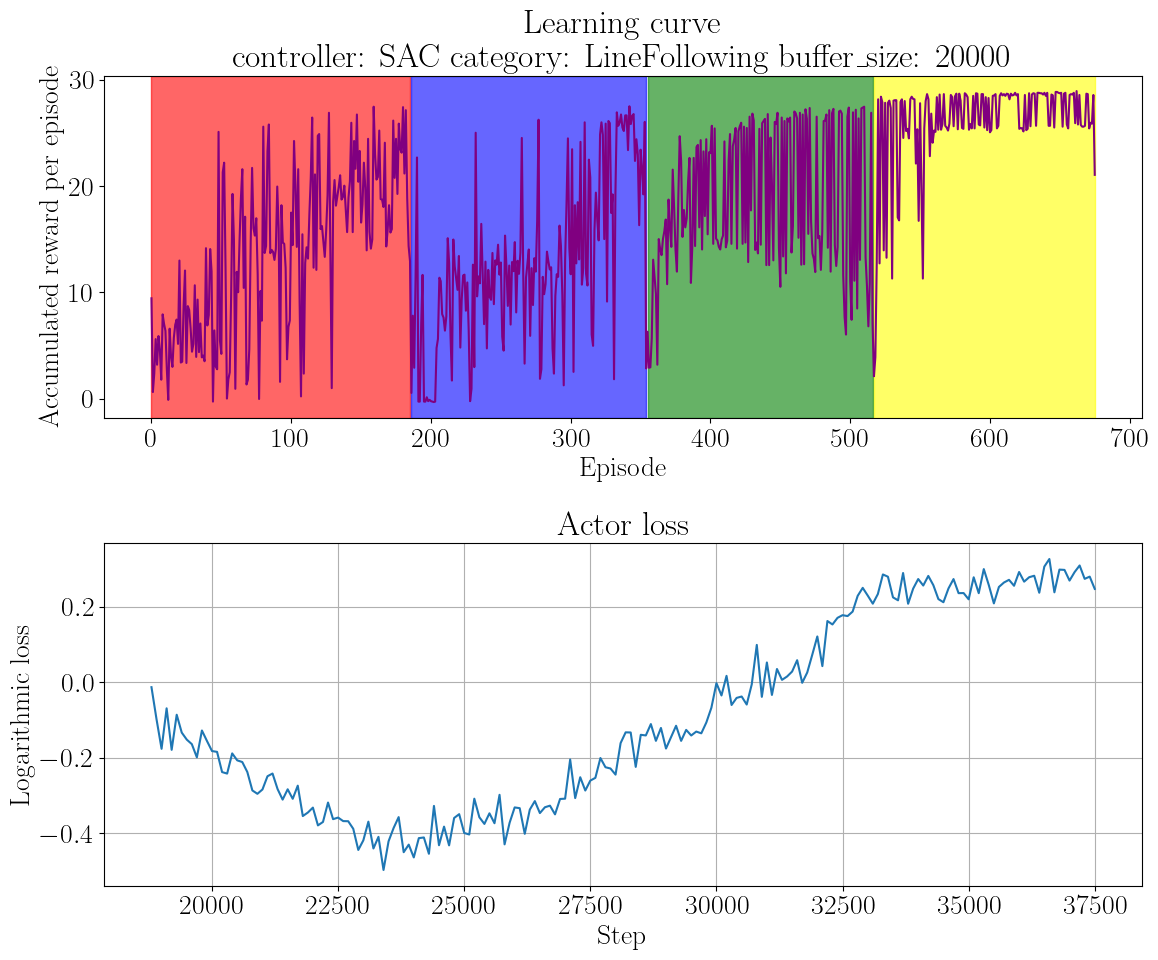

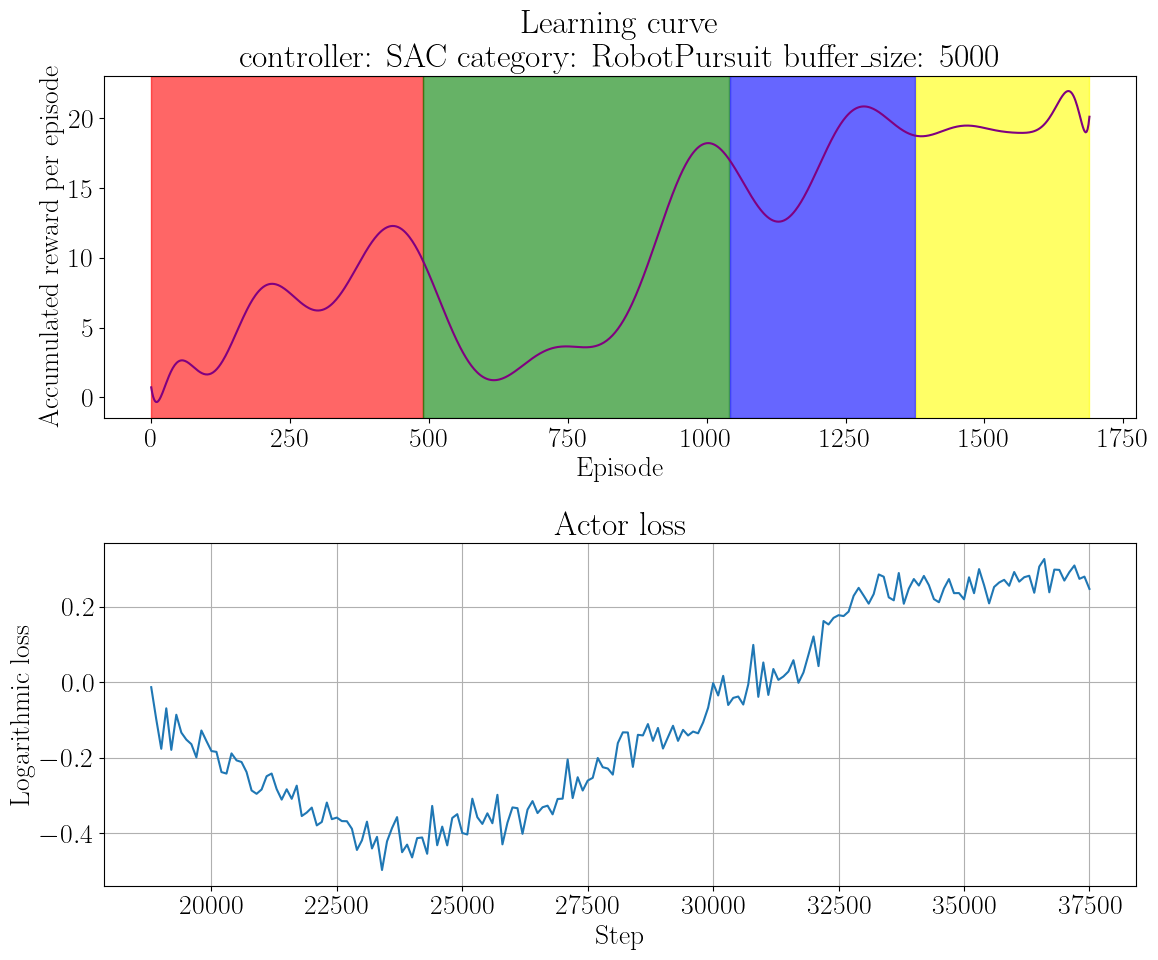

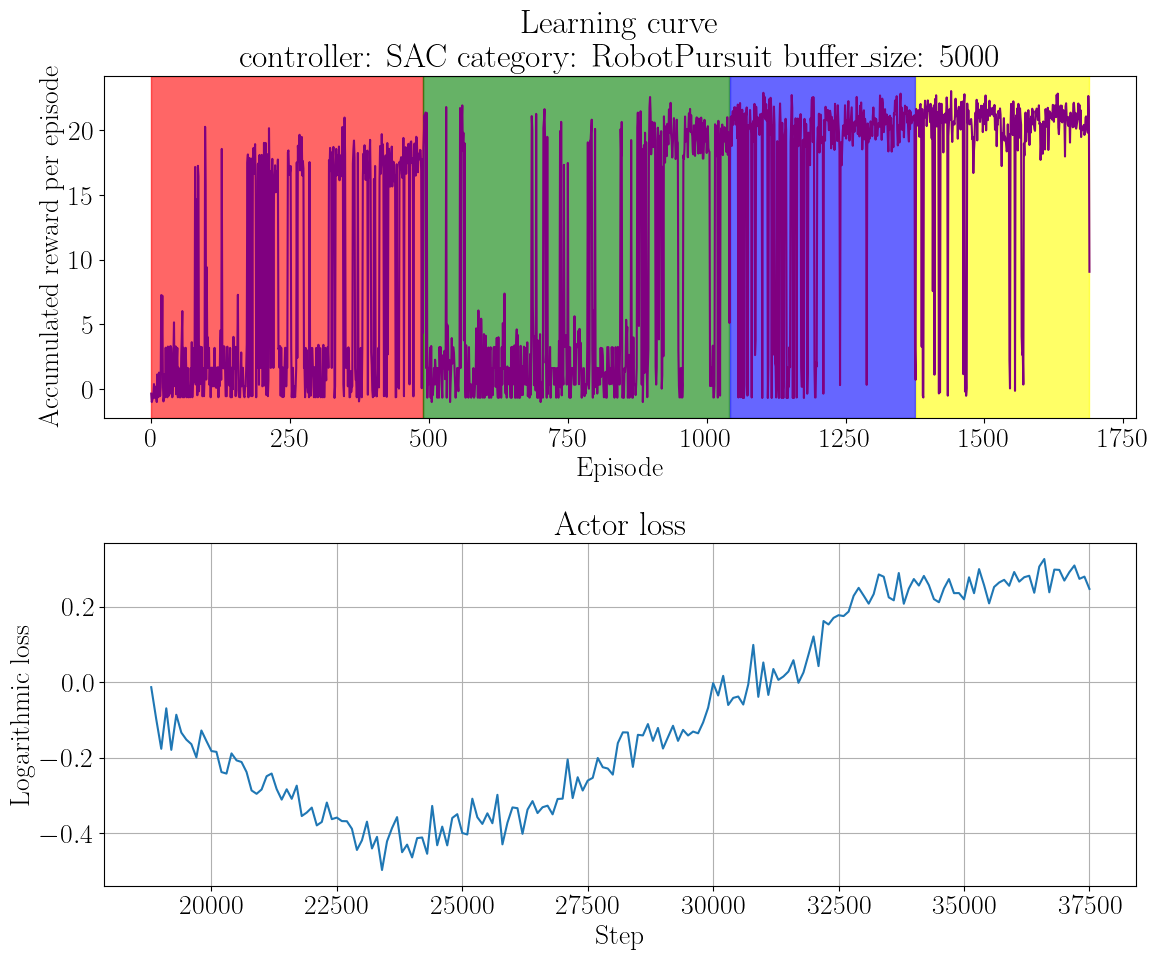

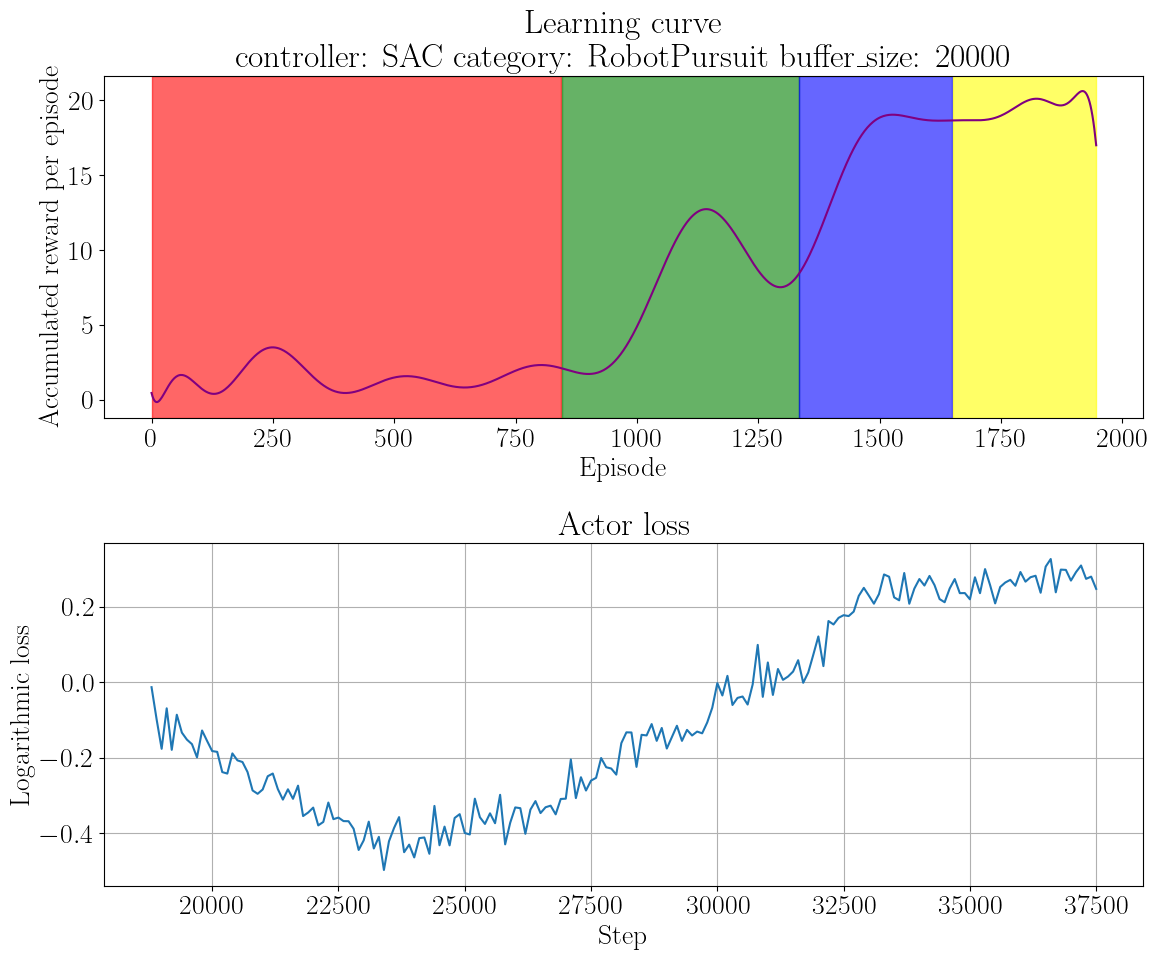

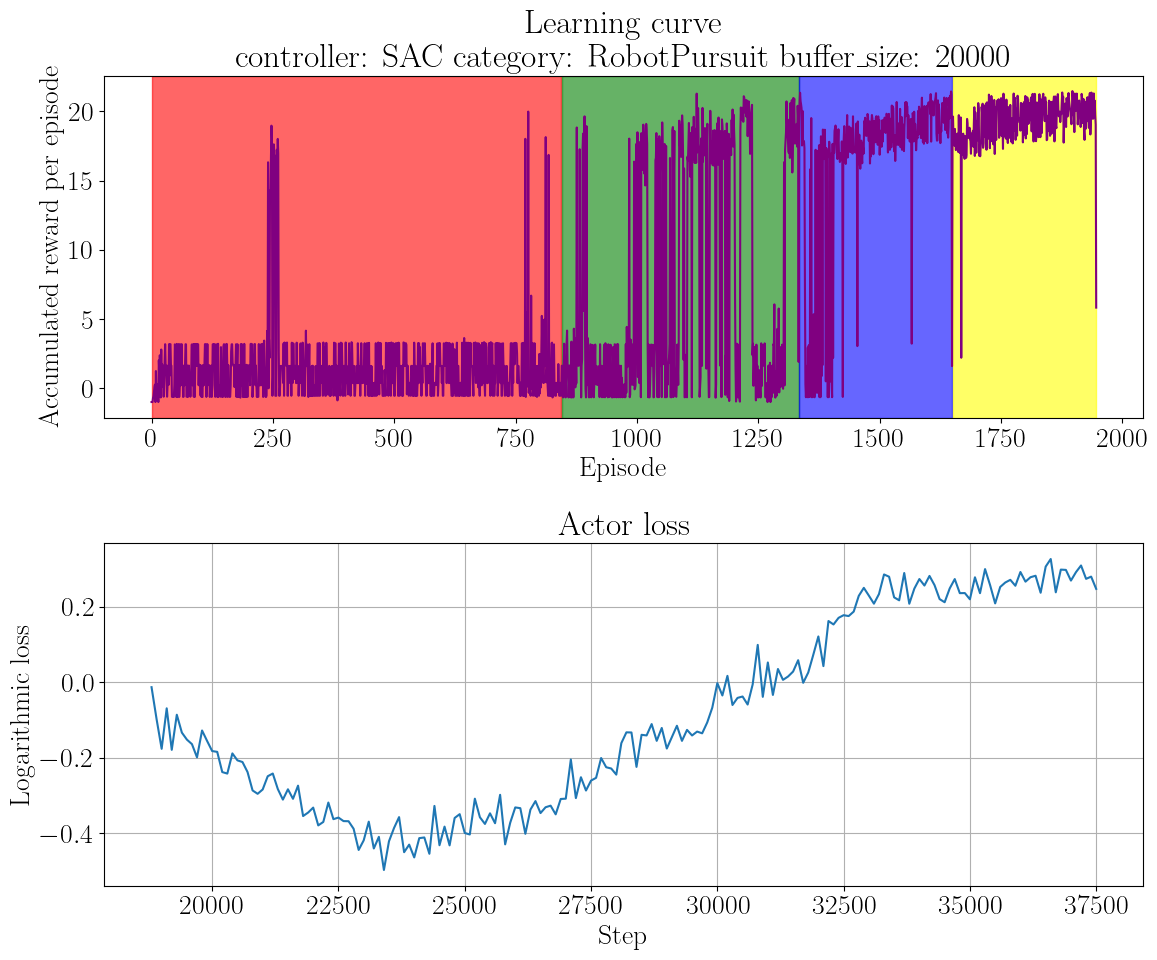

In [278]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20
})
# import matplotlib
# %matplotlib inline

def interpolate(X_, Y_):
    N_SAMPLE_INTER=1000

    degree = 30
    coeffs = np.polyfit(X_, Y_, degree)
    X_ = np.linspace(X_.min(), X_.max(), N_SAMPLE_INTER)
    Y_ = np.polyval(coeffs, X_)

    return X_, Y_

def plot_learning_curve(index, index_names, df, title="Learning curve", ax=None, use_interpolate=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    # Filter exploration actions
    tmp_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
    tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
    tmp_group_df = tmp_df.groupby("iteration_id")

    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "last", 
        "task_name": "last",
        "step_id": "last"
        })
    
    # Re-assign index for ploting
    tmp_group_df = tmp_group_df.reset_index()
    tmp_group_df.iteration_id = tmp_group_df.reset_index().index

    if not use_interpolate:
        tmp_group_df = tmp_group_df.set_index("iteration_id")
        tmp_group_df.plot(y="current_undiscounted_value", ax=ax, color="purple")
    else:
        ax.plot(*interpolate(tmp_group_df.iteration_id, tmp_group_df.current_undiscounted_value), color="purple")
        

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.6, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Accumulated reward per episode')
    ax.set_title(
        f'{title}\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()

    return "_".join([f"{a}_{b}" for a, b in list(zip(index_names, index))]) + "_interp_{}".format(1 if use_interpolate else 0)


for id in group_df.index:
    for interp in [True, False]:
        fig, ax = plt.subplots(2, 1, figsize=(12, 10))
        title = plot_learning_curve(id, 
                                    group_df.index.names, 
                                    df[df.phase=="train"], 
                                    ax=ax[0],
                                    use_interpolate=interp)
        
        actor_df["steps"] = [100 * i for i in range(len(actor_df))]
        actor_df[actor_df.experiment_path == df.experiment_path.values[0]].plot(x="steps", y="actor_loss", ax=ax[1])
        ax[1].set_title("Actor loss")
        ax[1].set_ylabel("Logarithmic loss")
        ax[1].set_xlabel("Step")
        ax[1].legend().remove()
        ax[1].grid()
        # plot_learning_curve(group_df.index[1], group_df.index.names, df)
        # plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
        # plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)
        # plt.show()
        plt.tight_layout()
        os.makedirs("./media", exist_ok=True)
        fig.savefig("./media/{}.pdf".format(title))

In [279]:
df[df.phase=="train"].set_index("iteration_id").current_undiscounted_value.values[-30:]

array([21.83673469, 22.81632653, 23.75510204, 24.73469388, 25.67346939,
       26.65306122, 27.63265306, 28.57142857,  0.73469388,  1.59183673,
        2.57142857,  3.51020408,  4.44897959,  5.42857143,  6.40816327,
        7.3877551 ,  8.36734694,  9.34693878, 10.32653061, 11.30612245,
       12.24489796, 13.2244898 , 14.20408163, 15.18367347, 16.16326531,
       17.14285714, 18.12244898, 19.10204082, 20.08163265, 21.06122449])

In [280]:
df = df.reset_index()
df[df.iteration_id==1]

,controller,category,buffer_size,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,...,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,is_reset_buffer,learning_starts,trained_task
0,SAC,LineFollowing,5000,0,0.000,0.489796,None,0.489796,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,250,circle_red
1,SAC,LineFollowing,5000,1,0.000,0.285714,None,0.775510,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,250,circle_red
2,SAC,LineFollowing,5000,2,0.165,0.244898,None,1.020408,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,250,circle_red
3,SAC,LineFollowing,5000,3,0.330,0.285714,None,1.306122,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,250,circle_red
4,SAC,LineFollowing,5000,4,0.495,0.204082,None,1.510204,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,250,circle_red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77363,SAC,LineFollowing,20000,25,3.960,0.530612,None,5.714286,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,250,circle_red
77364,SAC,LineFollowing,20000,26,4.125,0.530612,None,6.244898,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,250,circle_red
77365,SAC,LineFollowing,20000,27,4.290,0.571429,None,6.816327,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,250,circle_red
77366,SAC,LineFollowing,20000,28,4.455,0.612245,None,7.428571,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,250,circle_red


In [281]:
df.running_objective.describe()

count    106338.000000
mean          0.751099
std           1.415888
min          -1.000000
25%           0.326531
50%           0.675000
75%           0.897959
max          10.000000
Name: running_objective, dtype: float64

In [282]:
def postprocess_linefollowing(df):
    if not df.index.is_integer():
        df = df.reset_index()

    df["catch_the_line"] = df.running_objective.apply(lambda x: x > 0.7)
    return df

In [283]:
df = postprocess_linefollowing(df)

analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

if "catch_the_line" in df.columns:
    agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
    agg['catch_the_line'] = 'sum'

    analyse_group_df = analyse_group_df.agg(agg)
else:
    analyse_group_df = analyse_group_df.last()

analyse_group_df

/tmp/ipykernel_1173383/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Angular Velocity [rad/s]  Image pixel 0  \
task_name       iteration_id                                            
blue_sphere     1589                        -10.733941       0.266667   
                1590                          1.156801       0.854902   
                1591                         14.385999       0.854902   
                1592                         15.641314       0.854902   
                1593                          9.094050       0.854902   
...                                                ...            ...   
yellow_cylinder 2347                         13.181025       0.854902   
                2348                        -12.075295       0.862745   
                2349                          9.604338       0.858824   
                2350                         15.939980       0.854902   
                2351                          1.733561       0.854902   

                              Image pixel 1  Image pixel 10  Image pixel 100  \
task_name       iteration_id                                                   
blue_sphere     1589               0.266667        0.254902         0.168627   
                1590               0.854902        0.145098         0.243137   
                1591               0.854902        0.854902         0.243137   
                1592               0.854902        0.854902         0.250980   
                1593               0.854902        0.854902         0.278431   
...                                     ...             ...              ...   
yellow_cylinder 2347               0.854902        0.862745         0.713726   
                2348               0.862745        0.847059         0.854902   
                2349               0.858824        0.858824         0.694118   
                2350               0.854902        0.858824         0.772549   
                2351               0.854902        0.854902         0.811765   

                              Image pixel 1000  Image pixel 1001  \
task_name       iteration_id                                       
blue_sphere     1589                  0.290196          0.290196   
                1590                  0.290196          0.290196   
                1591                  0.290196          0.290196   
                1592                  0.290196          0.290196   
                1593                  0.290196          0.290196   
...                                        ...               ...   
yellow_cylinder 2347                  0.290196          0.290196   
                2348                  0.290196          0.290196   
                2349                  0.290196          0.290196   
                2350                  0.290196          0.290196   
                2351                  0.290196          0.290196   

                              Image pixel 1002  Image pixel 1003  \
task_name       iteration_id                                       
blue_sphere     1589                  0.290196          0.290196   
                1590                  0.290196          0.290196   
                1591                  0.290196          0.290196   
                1592                  0.290196          0.290196   
                1593                  0.290196          0.290196   
...                                        ...               ...   
yellow_cylinder 2347                  0.290196          0.290196   
                2348                  0.290196          0.290196   
                2349                  0.290196          0.290196   
                2350                  0.290196          0.290196   
                2351                  0.290196          0.290196   

                              Image pixel 1004  ...  index  is_reset_buffer  \
task_name       iteration_id                    ...                           
blue_sphere     1589                  0.290196  ...     14            False   
                1590            

# Evaluation

In [284]:
def experiment_sort_index(index):
    print(index)
    if index.name == "category":
        category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]nt(index)
    # if index.name == "category":
    #     category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]
    
    if index.name in ["trained_task", "task_name"]:
        lf_list = ["circle_red", "circle_blue", "circle_green", "circle_yellow"]
        rp_list = ["red_cube", "green_capsule", "blue_sphere", "yellow_cylinder"]

        common_list = lf_list + rp_list
        return [common_list.index(n) for n in index]
    
    return [a for a in index]

In [287]:
df = postprocess_linefollowing(df)

def pivot_success(df):
    if "eval" in df.phase.unique():
        analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

        if "catch_the_line" in df.columns:
            agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
            agg['catch_the_line'] = 'sum'

            analyse_group_df = analyse_group_df.agg(agg)
        else:
            analyse_group_df = analyse_group_df.last()

        def is_solved_task(row):
            if row.category == "LineFollowing":
                return row.catch_the_line > 20

            if row.category == "PushingObject":
                if row.task_name in ["blue", "yellow"]:
                    return row.running_objective == 10
                
                if row.task_name in ["red", "green"]:
                    return row.running_objective != -10

            if row.category == "RobotPursuit":
                return row.running_objective == 10
            
            return False

        def aggregate_function(series):
            sucess = np.sum(series)
            total = series.count()
            return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

        analyse_group_df = analyse_group_df.reset_index()
        analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

        analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
        # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

        pivot_table = pd.pivot_table(
            analyse_group_df.reset_index(), 
            columns=['controller', 'buffer_size', 'trained_task'],
            index=["category", "task_name"], 
            values="completion", aggfunc=aggregate_function
        )
        
        pivot_table = pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)
    else:
        pivot_table = None
    
    return pivot_table

pivot_success(df[df.category == "LineFollowing"])

/tmp/ipykernel_1173383/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([5000, 5000, 5000, 5000, 20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow',
       'circle_blue', 'circle_green', 'circle_red', 'circle_yellow'],
      dtype='object', name='trained_task')


controller                              SAC                                  \
buffer_size                           5000                                    
trained_task                     circle_red     circle_blue    circle_green   
category      task_name                                                       
LineFollowing circle_red     01 / 01 = 1.00  17 / 17 = 1.00  14 / 23 = 0.61   
              circle_blue               NaN  11 / 17 = 0.65  23 / 23 = 1.00   
              circle_green              NaN             NaN  06 / 23 = 0.26   
              circle_yellow             NaN             NaN             NaN   

controller                                                                   \
buffer_size                                           20000                   
trained_task                  circle_yellow      circle_red     circle_blue   
category      task_name                                                       
LineFollowing circle_red     00 / 24 = 0.00  30 / 30 = 1.00  30 / 30 = 1.00   
              circle_blue    24 / 24 = 1.00             NaN  30 / 30 = 1.00   
              circle_green   13 / 24 = 0.54             NaN             NaN   
              circle_yellow  12 / 24 = 0.50             NaN             NaN   

controller                                                   
buffer_size                                                  
trained_task                   circle_green   circle_yellow  
category      task_name                                      
LineFollowing circle_red     30 / 30 = 1.00  30 / 30 = 1.00  
              circle_blue    30 / 30 = 1.00  30 / 30 = 1.00  
              circle_green   16 / 30 = 0.53  30 / 30 = 1.00  
              circle_yellow             NaN  30 / 30 = 1.00

In [288]:
pivot_success(df[df.category == "RobotPursuit"])

Index(['RobotPursuit', 'RobotPursuit', 'RobotPursuit', 'RobotPursuit'], dtype='object', name='category')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([5000, 5000, 5000, 5000, 20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder',
       'blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'],
      dtype='object', name='trained_task')


controller                               SAC                                  \
buffer_size                            5000                                    
trained_task                        red_cube   green_capsule     blue_sphere   
category     task_name                                                         
RobotPursuit red_cube         23 / 30 = 0.77  30 / 30 = 1.00  30 / 30 = 1.00   
             green_capsule               NaN  30 / 30 = 1.00  30 / 30 = 1.00   
             blue_sphere                 NaN             NaN  30 / 30 = 1.00   
             yellow_cylinder             NaN             NaN             NaN   

controller                                                                    \
buffer_size                                            20000                   
trained_task                 yellow_cylinder        red_cube   green_capsule   
category     task_name                                                         
RobotPursuit red_cube         30 / 30 = 1.00  00 / 30 = 0.00  30 / 30 = 1.00   
             green_capsule    30 / 30 = 1.00             NaN  30 / 30 = 1.00   
             blue_sphere      30 / 30 = 1.00             NaN             NaN   
             yellow_cylinder  30 / 30 = 1.00             NaN             NaN   

controller                                                    
buffer_size                                                   
trained_task                     blue_sphere yellow_cylinder  
category     task_name                                        
RobotPursuit red_cube         30 / 30 = 1.00  30 / 30 = 1.00  
             green_capsule    30 / 30 = 1.00  30 / 30 = 1.00  
             blue_sphere      30 / 30 = 1.00  30 / 30 = 1.00  
             yellow_cylinder             NaN  30 / 30 = 1.00

In [ ]:
def pivot_avg(df):
    if "eval" in df.phase.unique():
        analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

        if "catch_the_line" in df.columns:
            agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
            agg['catch_the_line'] = 'sum'

            analyse_group_df = analyse_group_df.agg(agg)
        else:
            analyse_group_df = analyse_group_df.last()

        def is_solved_task(row):
            if row.category == "LineFollowing":
                return row.catch_the_line > 20

            if row.category == "PushingObject":
                if row.task_name in ["blue", "yellow"]:
                    return row.running_objective == 10
                
                if row.task_name in ["red", "green"]:
                    return row.running_objective != -10

            if row.category == "RobotPursuit":
                return row.running_objective == 10
            
            return False

        def aggregate_function(series):
            sucess = np.sum(series)
            total = series.count()
            return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

        analyse_group_df = analyse_group_df.reset_index()
        analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

        analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
        # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

        pivot_table = pd.pivot_table(
            analyse_group_df.reset_index(), 
            columns=['controller', 'buffer_size', 'trained_task'],
            index=["category", "task_name"], 
            values="current_undiscounted_value", aggfunc="mean"
        )
        
        pivot_table = pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)
    else:
        pivot_table = None

    return pivot_table

pivot_avg(df[df.category == "LineFollowing"])
# df.head()

Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([5000, 5000, 5000, 5000, 20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow',
       'circle_blue', 'circle_green', 'circle_red', 'circle_yellow'],
      dtype='object', name='trained_task')


controller                         SAC                                         \
buffer_size                      5000                                           
trained_task                circle_red circle_blue circle_green circle_yellow   
category      task_name                                                         
LineFollowing circle_red     27.918367   26.705882    25.142857      1.190476   
              circle_blue          NaN   25.591837    26.102928     26.049320   
              circle_green         NaN         NaN    15.607808     15.096939   
              circle_yellow        NaN         NaN          NaN     17.136054   

controller                                                                     
buffer_size                      20000                                         
trained_task                circle_red circle_blue circle_green circle_yellow  
category      task_name                                                        
LineFollowing circle_red     24.765986   26.289796    26.895238     26.680272  
              circle_blue          NaN   25.489796    26.843537     26.937415  
              circle_green         NaN         NaN    18.074830     26.297959  
              circle_yellow        NaN         NaN          NaN     27.295238

In [ ]:
pivot_avg(df[df.category == "RobotPursuit"])

Index(['RobotPursuit', 'RobotPursuit', 'RobotPursuit', 'RobotPursuit'], dtype='object', name='category')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='trained_task')


controller                         SAC                            \
buffer_size                      20000                             
trained_task                  red_cube green_capsule blue_sphere   
category     task_name                                             
RobotPursuit red_cube         1.022733     19.006668   19.620471   
             green_capsule         NaN     19.366896   18.840196   
             blue_sphere           NaN           NaN   19.936745   
             yellow_cylinder       NaN           NaN         NaN   

controller                                    
buffer_size                                   
trained_task                 yellow_cylinder  
category     task_name                        
RobotPursuit red_cube              20.003329  
             green_capsule         19.601606  
             blue_sphere           19.093131  
             yellow_cylinder       19.996201